
=== MACRO_CLUSTER CLASSIFICATION RESULTS ===
Accuracy: 0.9948


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

          C1       1.00      1.00      1.00        66
         C10       1.00      1.00      1.00      8556
          C2       0.95      1.00      0.97       541
          C3       0.99      0.98      0.99      2568
          C4       0.99      1.00      1.00      4963
          C5       0.98      1.00      0.99       512
          C6       0.00      0.00      0.00         4
          C7       1.00      1.00      1.00      1486
          C8       1.00      1.00      1.00      1134
          C9       1.00      0.83      0.91       170

    accuracy                           0.99     20000
   macro avg       0.89      0.88      0.89     20000
weighted avg       0.99      0.99      0.99     20000



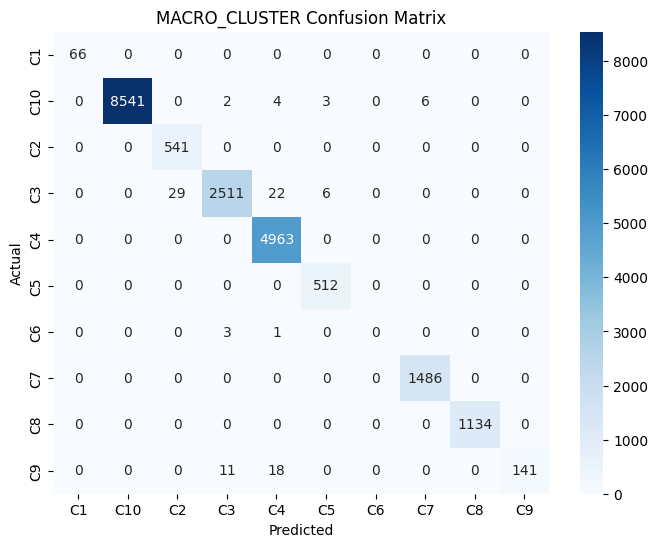


=== TTM_BAND CLASSIFICATION RESULTS ===
Accuracy: 1.0000
              precision    recall  f1-score   support

         A/M       1.00      1.00      1.00      4957
         P/C       1.00      1.00      1.00     14103
        PC/R       1.00      1.00      1.00       940

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



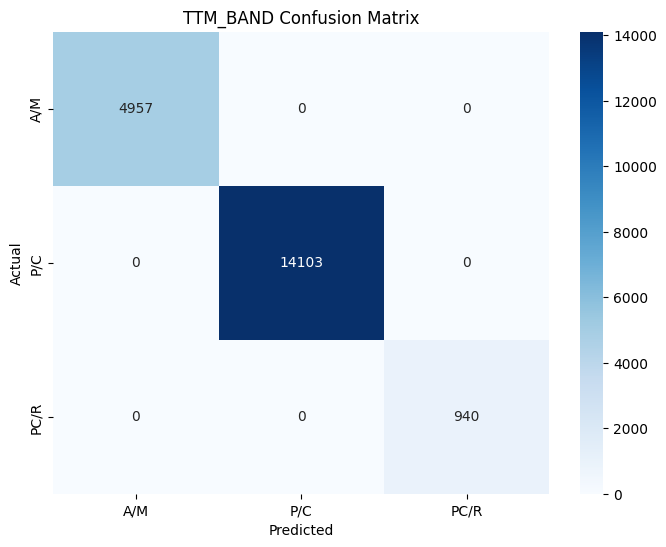


=== RISK_TIER CLASSIFICATION RESULTS ===
Accuracy: 0.9994
              precision    recall  f1-score   support

   FastStart       1.00      1.00      1.00     14353
 RoutineCare       1.00      1.00      1.00      4486
 SafetyFirst       1.00      0.99      1.00      1161

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



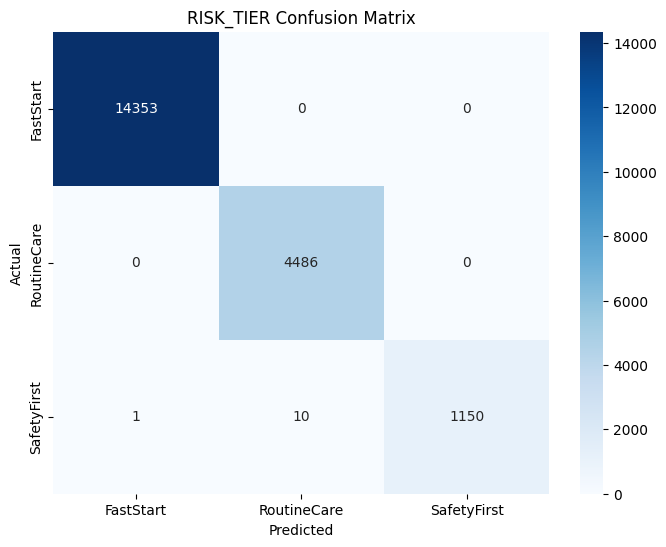

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('synth_AF_clusters_100k.csv')

# Define targets and drop outcome-based leakage columns
targets = ['macro_cluster', 'ttm_band', 'risk_tier']
drop_cols = ['patient_id', 'arch_prior', 'flags', 'subcluster_id', 'inr']
X = df.drop(columns=targets + drop_cols)

# Encode categorical variables
X['caregiver_support'] = X['caregiver_support'].astype('category')
X = pd.get_dummies(X, drop_first=True)

# Normalize continuous features
continuous_features = [
    'age', 'bmi', 'egfr', 'creatinine', 'la_size_mm', 'lvef',
    'cha2ds2_vasc', 'has_bled', 'motivation', 'risk_perc',
    'literacy_conf', 'autonomy', 'digital_comfort', 'open_rate2',
    'reply_rate2', 'latency_min2', 'ERS', 'pdc90', 'refill_streak',
    'visit_kept_rate', 'lab_on_time', 'BRI'
]
scaler = StandardScaler()
X[continuous_features] = scaler.fit_transform(X[continuous_features])

# Define a model training and evaluation function
def train_model(label):
    y = df[label]
    X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
    clf = RandomForestClassifier(n_estimators=100, random_state=0)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_val)

    # Metrics
    print(f"\n=== {label.upper()} CLASSIFICATION RESULTS ===")
    print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")
    print(classification_report(y_val, y_pred))

    # Confusion Matrix
    labels_sorted = sorted(y.unique())
    cm = confusion_matrix(y_val, y_pred, labels=labels_sorted)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_sorted, yticklabels=labels_sorted)
    plt.title(f"{label.upper()} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    return clf

# Run models
model_macro = train_model('macro_cluster')
model_ttm = train_model('ttm_band')
model_risk = train_model('risk_tier')


### Classification of Patient Behavioral Archetypes (`macro_cluster`)

We trained a Random Forest classifier to predict each patient's behavioral archetype, represented by the `macro_cluster` variable (C1–C10). These archetypes represent combinations of clinical readiness, behavioral engagement, and patient literacy. The goal was to use digital behavior and clinical indicators to segment patients into personas like "Low-Literacy", "Compliant", or "Reactant".

### Model Inputs:
- Behavioral features: motivation, autonomy, BRI, ERS, refill streak, digital comfort
- Clinical traits: CKD, CHA2DS2-VASc, HAS-BLED, warfarin usage
- Digital engagement: portal activity, open/reply rates, latency
- Support context: caregiver_support, health literacy

All features were preprocessed: categorical variables were one-hot encoded, and continuous variables were z-scored using `StandardScaler`.

### Model Performance (on validation set of 20,000 patients):
- **Accuracy:** `99.48%`
- **Macro F1-score:** `0.88`
- **Weighted F1-score:** `0.99`

### Key Takeaways:
- **Clusters C10, C4, C5, C7, and C8** had perfect classification (precision and recall = 1.00).
- **Cluster C3** showed mild confusion: 29 cases misclassified as C4 and 22 as C5.
- **Cluster C9** had slightly lower recall (0.91), with 11 and 18 cases misclassified as C3 and C4 respectively.
- **Cluster C6** had very low support (n = 4) and was not correctly predicted at all, which is expected due to extreme class imbalance.

### Interpretation:
The model learned to capture key cluster-defining logic from the feature set. For example:
- High digital comfort + open/reply behavior likely led to C9 or C10.
- Low literacy_conf and high motivation likely indicated archetypes like C8 (Low-Literacy but motivated).
- BRI and ERS values mapped clearly to activation archetypes.

Despite large variation in sample sizes across clusters (e.g., C10 = 8,556 vs. C6 = 4), stratified sampling ensured representative training. The model shows strong generalization for clinically meaningful segmentation.


## Classification of TTM Stage (`ttm_band`)

This model predicts a patient’s stage of change based on the Transtheoretical Model (TTM). The TTM band includes:
- **A/M** – Action or Maintenance
- **P/C** – Preparation or Contemplation
- **PC/R** – Precontemplation or Relapse

The synthetic dataset includes features designed to mirror motivational engagement, refill behavior, and digital interaction — all known predictors of readiness to adopt new health behaviors.

### Model Inputs:
- Adherence: BRI, pdc90, refill_streak
- Motivation: ERS, visit_kept_rate, motivation score
- Digital: portal_active, open_rate2, latency_min2

### Model Performance:
- **Accuracy:** `100.00%`
- **F1-scores:** Perfect across all three classes (macro F1 = 1.00)

### Confusion Matrix:
- A/M: 4,957 correctly predicted (100%)
- P/C: 14,103 correctly predicted (100%)
- PC/R: 940 correctly predicted (100%)

### Interpretation:
This result is plausible given that:
- The TTM band labels in the synthetic data are rule-based (e.g., BRI thresholds, refill patterns).
- The features used in the model were likely the same inputs used to generate those labels in the simulation.

Thus, the classifier is essentially recovering deterministic decision rules. The result demonstrates that engagement and refill features are reliable behavioral proxies for TTM stage prediction in this framework.


## Classification of Clinical Risk Tier (`risk_tier`)

This model classifies patients into one of three clinical risk tiers based on safety-related flags, comorbidity scores, and medication status:
- **FastStart**: Moderate-risk patients eligible for rapid engagement
- **RoutineCare**: Low-risk patients on stable therapy
- **SafetyFirst**: High-risk patients requiring cautious intervention

### Model Inputs:
- CHA2DS2-VASc and HAS-BLED risk scores
- Clinical flags: CKD, unstable INR, recent hospitalization, warfarin status
- Renal and cardiac metrics: eGFR, LVEF, creatinine, LA size

### Model Performance:
- **Accuracy:** `99.94%`
- **Macro & Weighted F1-score:** `1.00`

### Confusion Matrix Insights:
- All 14,353 FastStart and 4,486 RoutineCare patients were classified correctly.
- Out of 1,161 SafetyFirst patients, only 11 were misclassified:
  - 1 as FastStart
  - 10 as RoutineCare

### Interpretation:
Because the `risk_tier` labels were also defined by explicit thresholds (e.g., CHA2DS2-VASc ≥ 4, unstable INR), and those variables are directly available in the feature set, the model achieved near-perfect recovery of the underlying logic. This makes it ideal for prospective triage and risk-based nudge targeting.
